# 🛍️ Customer Segmentation in Retail using RFM Analysis and K-Means Clustering

In [1]:
import pandas as pd

In [3]:
df = pd.read_excel("Online Retail.xlsx")


In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 📊 Dataset Description

The dataset used in this project is the Online Retail dataset, which contains transactional data of a UK-based e-commerce company.

### Key Columns:
- InvoiceNo → Unique order ID
- StockCode → Product ID
- Description → Product name
- Quantity → Number of items purchased
- InvoiceDate → Date of transaction
- UnitPrice → Price per item
- CustomerID → Unique customer ID
- Country → Customer location

In [5]:
df.shape

(541909, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [7]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


## 🧹 Data Cleaning

The following steps were performed to clean the dataset:

- Removed records with missing CustomerID
- Removed cancelled transactions (InvoiceNo starting with 'C')
- Filtered out rows with non-positive Quantity and UnitPrice
- Created a new column `Sales = Quantity × UnitPrice`

These steps ensure that only valid transactions are used for analysis.

In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
df = df.dropna(subset=['CustomerID'])

In [16]:
df.shape

(397884, 9)

In [10]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [11]:
df = df[df['Quantity'] > 0]

In [12]:
df = df[df['UnitPrice'] > 0]

In [13]:
df['Sales'] = df['Quantity'] * df['UnitPrice']

In [14]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [17]:
df.shape

(397884, 9)

In [18]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Sales          0
dtype: int64

In [19]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [20]:
reference_date = df['InvoiceDate'].max()

In [23]:
frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()
frequency = frequency.reset_index()

frequency.head()

,CustomerID,InvoiceNo
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


In [24]:
frequency.columns = ['CustomerID', 'Frequency']

In [25]:
monetary = df.groupby('CustomerID')['Sales'].sum()
monetary = monetary.reset_index()

monetary.columns = ['CustomerID', 'Monetary']

monetary.head()

,CustomerID,Monetary
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [26]:
last_date = df.groupby('CustomerID')['InvoiceDate'].max()
last_date = last_date.reset_index()

last_date.head()

,CustomerID,InvoiceDate
0,12346.0,2011-01-18 10:01:00
1,12347.0,2011-12-07 15:52:00
2,12348.0,2011-09-25 13:13:00
3,12349.0,2011-11-21 09:51:00
4,12350.0,2011-02-02 16:01:00


In [27]:
last_date['Recency'] = (reference_date - last_date['InvoiceDate']).dt.days

last_date = last_date[['CustomerID', 'Recency']]

last_date.head()

,CustomerID,Recency
0,12346.0,325
1,12347.0,1
2,12348.0,74
3,12349.0,18
4,12350.0,309


In [28]:
rfm = frequency.merge(monetary, on='CustomerID')
rfm = rfm.merge(last_date, on='CustomerID')

rfm.head()

,CustomerID,Frequency,Monetary,Recency
0,12346.0,1,77183.60,325
1,12347.0,7,4310.00,1
2,12348.0,4,1797.24,74
3,12349.0,1,1757.55,18
4,12350.0,1,334.40,309


In [29]:
rfm.shape

(4338, 4)

In [30]:
rfm_data = rfm[['Recency', 'Frequency', 'Monetary']]

rfm_data.head()

,Recency,Frequency,Monetary
0,325,1,77183.60
1,1,7,4310.00
2,74,4,1797.24
3,18,1,1757.55
4,309,1,334.40


## ⚙️ Data Scaling

The RFM features have different ranges (e.g., Monetary is much larger than Frequency).

To ensure equal importance of all features, StandardScaler was used to standardize the data before applying clustering.

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_data)

rfm_scaled[:5]

array([[ 2.33457414, -0.4250965 ,  8.35866818],
       [-0.90534032,  0.3544168 ,  0.25096626],
       [-0.17535959, -0.03533985, -0.02859601],
       [-0.73534481, -0.4250965 , -0.0330118 ],
       [ 2.17457836, -0.4250965 , -0.19134727]])

## 🤖 K-Means Clustering

K-Means clustering was applied to segment customers into 4 groups based on their RFM values.

Each customer was assigned to a cluster representing a specific behavioral group.

In [34]:
from sklearn.cluster import KMeans

wcss = []

for clusters in range(1, 11):
    
    model = KMeans(n_clusters=clusters, random_state=42)
    
    model.fit(rfm_scaled)
    
    error = model.inertia_
    
    wcss.append(error)

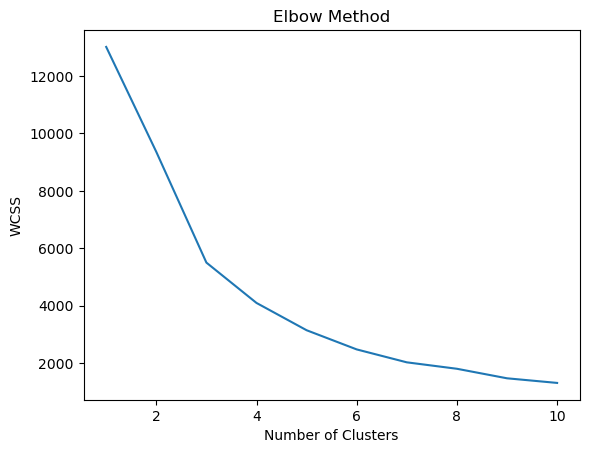

In [35]:
import matplotlib.pyplot as plt

plt.plot(range(1, 11), wcss)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [36]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [37]:
rfm.head()

,CustomerID,Frequency,Monetary,Recency,Cluster
0,12346.0,1,77183.60,325,3
1,12347.0,7,4310.00,1,0
2,12348.0,4,1797.24,74,0
3,12349.0,1,1757.55,18,0
4,12350.0,1,334.40,309,1


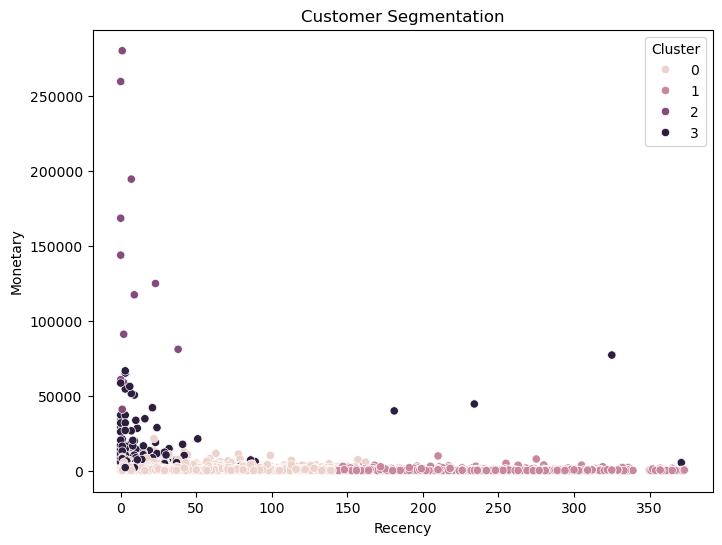

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Recency',
    y='Monetary',
    hue='Cluster',
    data=rfm
)

plt.title('Customer Segmentation')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.savefig("images/cluster_plot.png")
plt.show()


In [39]:
rfm.groupby('Cluster').mean()

,CustomerID,Frequency,Monetary,Recency
Cluster,,,,
0,15289.128356,3.682711,1359.049284,42.702685
1,15347.791940,1.552015,480.617480,247.075914
2,15435.000000,82.538462,127338.313846,6.384615
3,15212.857843,22.333333,12709.090490,14.500000
